### Multiple Linear Regression
**Multiple Linear Regression** is a statistical technique used to model the relationship between **one dependent variable** and **two or more independent variables.**

#### The General Formula:
$
Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_nX_n + \varepsilon
$

Where:
- **$Y$** = Dependent (target) variable
- **$X_1, X_2, ..., X_n$** = Independent (predictor) variables
- **$\beta_0$** = Intercept
- **$\beta_1, \beta_2, ..., \beta_n$** = Regression coefficients
- **$\varepsilon$** = Error term

Instead of fitting a **line**, multiple linear regression fits a **plane (or hyperplane)**, where each feature contributes **independently** to the final prediction.

#### Matrix Form
Matrix equation form:  
$
y = XW + b
$

Where:
- X -> feature matrix (n_samples × n_features)
- W -> weight vector
- y -> prediction vector

#### Cost Function:
Mean Squared Error:
$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$

#### Assumptions:
- Linearity – Relationship is linear
- Independence – Observations are independent
- Homoscedasticity – Constant variance of errors
- Normality – Errors are normally distributed
- No Multicollinearity – Predictors are not highly correlated

#### Training Using Gradient Descent (Concept)
- Initialize weights
- Predict
- Compute loss
- Compute gradients
- Update weights
- Repeat

### Use Case
#### House Price Prediction
A real estate platform (e.g., a property marketplace or brokerage firm) wants to **automatically estimate the market price of a house** when a seller lists a property.

#### Features (Inputs)
| Feature          | Description                 |
| ---------------- | --------------------------- |
| size_sqft        | Area of house               |
| bedrooms         | Number of bedrooms          |
| bathrooms        | Number of bathrooms         |
| age_years        | Age of property             |
| distance_city_km | Distance from city center   |
| school_rating    | Nearby school rating (1–10) |

#### Target (Output)
| Column | Meaning              |
| ------ | -------------------- |
| price  | Selling price in INR |

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [33]:
# Load Dataset

df = pd.read_csv("./data/house_prices_dataset.csv")

print("Shape : ", df.shape)
df.head()

Shape :  (2000, 7)


,size_sqft,bedrooms,bathrooms,age_years,distance_city_km,school_rating,price
0,675,7,1,2,7.29,2,20507618
1,1720,3,6,25,29.18,1,43993514
2,1037,5,3,9,1.82,5,29559754
3,3050,5,2,23,2.68,9,83944390
4,2103,4,5,20,12.91,10,60403577


In [34]:
# EDA

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   size_sqft         2000 non-null   int64  
 1   bedrooms          2000 non-null   int64  
 2   bathrooms         2000 non-null   int64  
 3   age_years         2000 non-null   int64  
 4   distance_city_km  2000 non-null   float64
 5   school_rating     2000 non-null   int64  
 6   price             2000 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 109.5 KB


,size_sqft,bedrooms,bathrooms,age_years,distance_city_km,school_rating,price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,2271.440000,3.986000,3.565000,14.749000,15.240025,5.516000,6.324986e+07
std,1001.965021,1.996947,1.717338,8.543096,8.584454,2.875566,2.809570e+07
min,501.000000,1.000000,1.000000,0.000000,0.500000,1.000000,1.103243e+07
25%,1422.000000,2.000000,2.000000,8.000000,7.682500,3.000000,3.951425e+07
50%,2287.500000,4.000000,4.000000,15.000000,15.190000,6.000000,6.357443e+07
75%,3128.500000,6.000000,5.000000,22.000000,22.925000,8.000000,8.732647e+07
max,3995.000000,7.000000,6.000000,29.000000,30.000000,10.000000,1.143401e+08


In [35]:
# Check Missing Values

df.isnull().sum()

size_sqft           0
bedrooms            0
bathrooms           0
age_years           0
distance_city_km    0
school_rating       0
price               0
dtype: int64

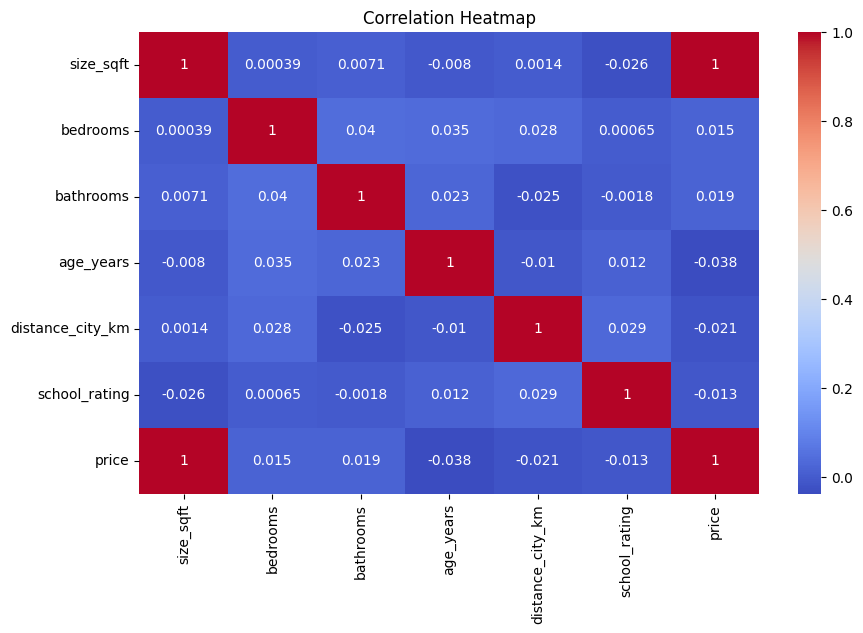

In [36]:
# Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

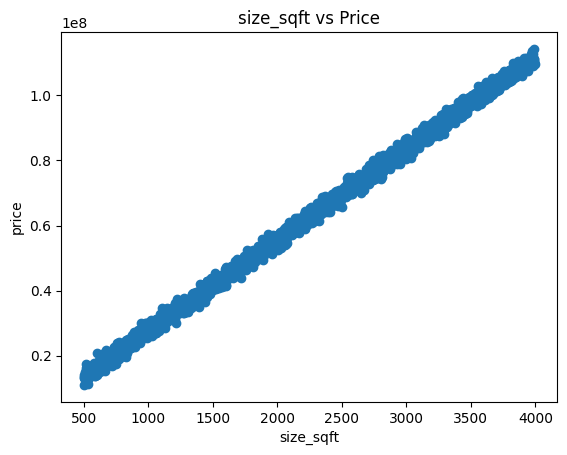

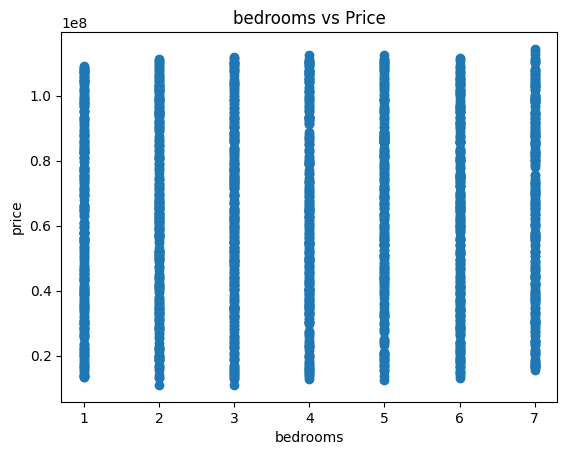

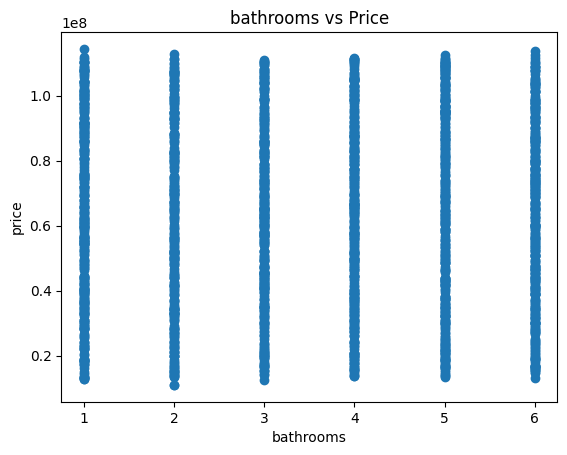

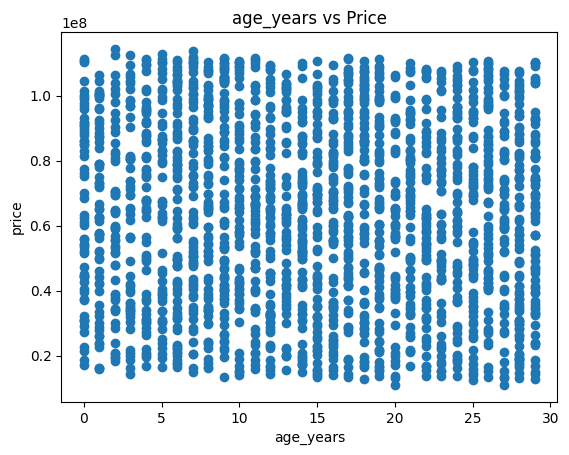

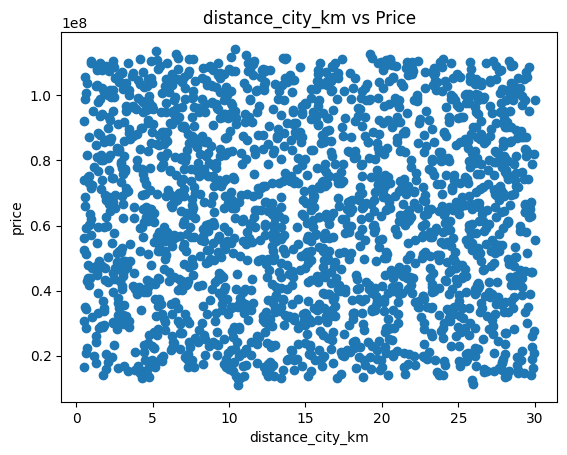

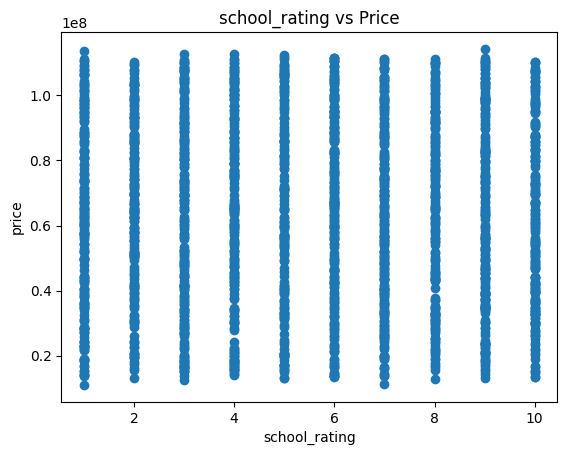

In [37]:
# Scatter Plot (Feature vs Price)

features = df.columns[:-1]

for col in features:
    plt.figure()
    plt.scatter(df[col], df["price"])
    plt.xlabel(col)
    plt.ylabel("price")
    plt.title(f"{col} vs Price")
    plt.show()


In [38]:
# Separate Features and Target

# axis = 0 -> rows, axis = 1 -> columns
X = df.drop("price", axis=1) # drop column
y = df["price"]

In [39]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# 80% training, 20% testing

In [44]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- fit() learns mean & std from training data
- transform() applies scaling
- NEVER fit on test data (prevents data leakage)

In [41]:
# Train Multiple Linear Regression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 483151.56614554516
RMSE: 606351.8918502082
R2 Score: 0.9995191725943954


##### Saving Model

In [45]:
import os
import joblib

os.makedirs("project-multiple_linear_regression", exist_ok=True)

model_path = os.path.join("project-multiple_linear_regression", "house_prices_model.pkl")
joblib.dump(model, model_path)

scaler_path = os.path.join("project-multiple_linear_regression", "scaler.pkl")
joblib.dump(scaler, scaler_path)
print("Model and Scaler Saved!")

Model and Scaler Saved!
